4.3節「その他の量子ダイナミクスシミュレーション」で紹介したブロック符号化（block encoding）と量子ビット化（qubitization）を実装してみよう。例として、2量子ビットのハミルトニアン
$$
H = c_0 X_0 + c_1 Z_0 + c_2 X_0 X_1 + c_3 Z_0 Z_1
$$
を考える。ここで、$c_0,c_1,c_2,c_3$は実数で、簡単のため全て正であると仮定する。このハミルトニアンのブロック符号化を構築し、
$$ H ' = \frac{H}{\alpha} = p_{00} X_0 + p_{01} Z_0 + p_{10} X_0 X_1 + p_{11} Z_0 Z_1
$$
と比較してみよう。ここで、$\alpha = c_0 + c_1 + c_2 + c_3$は正の定数で、$p_{00} = c_0 / \alpha, p_{01} = c_1 / \alpha, p_{10} = c_2 / \alpha, p_{11} = c_3 / \alpha$と定義した。
$p_{00} + p_{01} + p_{10} + p_{11} = 1$であることに注意しよう。

## ブロック符号化の実装
まずは$H'$のブロック符号化を、4.3.2節で紹介したユニタリの線型結合（LCU）を使って構築してみよう。
$H'$には4つのパウリ演算子があるので、2つの補助量子ビットが必要になる。
補助量子ビットの`00, 01, 10, 11`に対して、$X_0, Z_0, X_0 X_1, Z_0 Z_1$を対応させることにする。

式(4.24)で定義される$\mathrm{PREP}_a$演算子
$$
\mathrm{PREP}_a |00\rangle = \sqrt{p_{00}} |00\rangle + \sqrt{p_{01}} |01\rangle + \sqrt{p_{10}} |10\rangle + \sqrt{p_{11}} |11\rangle
$$
は以下のように、$Y$回転ゲート$R_Y$を複数用いて実装できる。

最初に0番目の量子ビットに角度$\theta_0 = 2 \arccos \left( \sqrt{p_{00} + p_{10}} \right)$の$Y$回転ゲートを作用させると、補助量子ビットの状態は（$1 - (p_{00} + p_{10}) = p_{01} + p_{11}$に注意）
$$
R_{Y_0}(\theta_0) |00\rangle =
\sqrt{p_{00} + p_{10}} |00\rangle + \sqrt{p_{01} + p_{11}} |01\rangle
$$
となる。
次に1番目の量子ビットに、0番目の量子ビットが`0`のときは角度$\theta_1^{(0)} = 2 \arccos \left( \sqrt{p_{00} / (p_{00} + p_{10})} \right)$の$R_Y$回転を、0番目の量子ビットが`1`のときは角度$\theta_1^{(1)} = 2 \arccos \left( \sqrt{p_{01} / (p_{01} + p_{11})} \right)$の$Y$回転ゲートを作用させるような制御回転ゲートを適用すると、補助量子ビットの状態は
$$
\begin{aligned}
&\sqrt{p_{00} + p_{10}} \left( \sqrt{\frac{p_{00}}{p_{00} + p_{10}}} |00\rangle + \sqrt{\frac{p_{10}}{p_{00} + p_{10}}} |10\rangle \right) \\
&+ \sqrt{p_{01} + p_{11}} \left( \sqrt{\frac{p_{01}}{p_{01} + p_{11}}} |01\rangle + \sqrt{\frac{p_{11}}{p_{01} + p_{11}}} |11\rangle \right) \\
&= \sqrt{p_{00}} |00\rangle + \sqrt{p_{01}} |01\rangle + \sqrt{p_{10}} |10\rangle + \sqrt{p_{11}} |11\rangle
\end{aligned}
$$
となり、$\mathrm{PREP}_a$の定義を満たす。
なお、この$\mathrm{PREP}_a$の構成法は量子ビットが大きい場合も同様に拡張できるので、興味のある読者は講義ノート https://www2.yukawa.kyoto-u.ac.jp/~qischool2019/mitaraiCTO.pdf の4.2.2節やそこで紹介されている原論文を参照してほしい。

以下の実装では、$\phi = \frac{\theta_1^{(0)} + \theta_1^{(1)}}{2}$, $\psi = \frac{\theta_1^{(0)} - \theta_1^{(1)}}{2}$という2つの角度を用いた$Y$回転ゲートとCNOTゲートを用いることで、所望の制御回転ゲートを構成している（図7.2の回路を参考に考えてみるとよい）。

In [ ]:
!pip install "quri-parts[qulacs]"

In [2]:
import numpy as np
from quri_parts.circuit import QuantumCircuit
from quri_parts.core.state import quantum_state, apply_circuit
from quri_parts.qulacs.simulator import evaluate_state_to_vector
from quri_parts.circuit.utils.circuit_drawer import draw_circuit

# 量子ビットの数
n_qubits = 4  # 0,1がシステムの量子ビット, 2,3が補助量子ビット
sys_0, sys_1 = 0, 1 # システム量子ビットのインデックス
anc_0, anc_1 = 2, 3 # 補助量子ビットのインデックス

# ハミルトニアンの係数
c0 = 1
c1 = 2
c2 = 3
c3 = 4

# 係数の規格化
alpha = c0 + c1 + c2 + c3
if alpha <= 0:
    raise ValueError("c0+c1+c2+c3 must be positive.")
if min(c0, c1, c2, c3) < 0:
    raise ValueError("This simple sample assumes c0,c1,c2,c3 >= 0.")

p00, p01, p10, p11 = c0 / alpha, c1 / alpha, c2 / alpha, c3 / alpha

def build_prepare_2anc(p00: float, p01: float, p10: float, p11: float, n_qubits, anc_0, anc_1) -> QuantumCircuit:
    # First qubit rotation
    theta0 = 2 * np.arccos(np.sqrt(p00 + p10))

    # Conditional second-qubit rotations
    theta1_if_q0_0 = 2 * np.arccos(np.sqrt(p00 / (p00 + p10)))
    theta1_if_q0_1 = 2 * np.arccos(np.sqrt(p01 / (p01 + p11)))

    # 2つのY回転ゲートを用いた制御回転ゲートの実装
    phi = 0.5 * (theta1_if_q0_0 + theta1_if_q0_1)
    psi = 0.5 * (theta1_if_q0_0 - theta1_if_q0_1)

    # PREP_aの回路を作成
    circ = QuantumCircuit(n_qubits)
    circ.add_RY_gate(anc_0, theta0)
    circ.add_RY_gate(anc_1, phi)
    circ.add_CNOT_gate(anc_0, anc_1)
    circ.add_RY_gate(anc_1, psi)
    circ.add_CNOT_gate(anc_0, anc_1)

    return circ

prep_check = build_prepare_2anc(p00, p01, p10, p11, n_qubits=2, anc_0=0, anc_1=1)

# 回路の図示
print("PREP_aの量子回路図:")
draw_circuit(prep_check)

# PREP_aの動作の確認
print("")
print("p00, p01, p10, p11:")
print(np.sqrt(p00), np.sqrt(p01), np.sqrt(p10), np.sqrt(p11))

state = quantum_state(2)
state = apply_circuit(prep_check, state)
state_vec = evaluate_state_to_vector(state)
print("PREP_aの出力状態ベクトル:")
print(state_vec.vector)

PREP_aの量子回路図:
   ___                          
  |RY |                         
--|0  |-----●---------------●---
  |___|     |               |   
   ___     _|_     ___     _|_  
  |RY |   |CX |   |RY |   |CX | 
--|1  |---|2  |---|3  |---|4  |-
  |___|   |___|   |___|   |___| 

p00, p01, p10, p11:
0.31622776601683794 0.4472135954999579 0.5477225575051661 0.6324555320336759
PREP_aの出力状態ベクトル:
[0.31622777+0.j 0.4472136 +0.j 0.54772256+0.j 0.63245553+0.j]


無事に$\mathrm{PREP}_a$の定義通りの状態が補助量子ビットに準備されていることがわかった。

次に、LCUのSELECT演算子 $\mathrm{SEL}$（式(4.25)）を実装しよう。
これはCNOTゲートやトフォリゲートなどを用いると可能であり、今回は図7.9のような最も愚直なQRAM実装と同じ形の量子回路を用いることにする。

In [3]:
def add_ccz(circ: QuantumCircuit, control0: int, control1: int, target: int) -> None:
    """多重制御ZゲートCCZの実装.
    アダマールゲートHについて HXH = Z であることを利用して、トフォリゲートCCXをCCZに変換している。"""
    circ.add_H_gate(target)
    circ.add_TOFFOLI_gate(control0, control1, target)
    circ.add_H_gate(target)

def build_select(n_qubits, anc_0, anc_1, sys_0, sys_1) -> QuantumCircuit:
    r"""  以下のユニタリを実装する。
      |00><00| \otimes X0   + |01><01| \otimes Z0
    + |10><10| \otimes X0X1 + |11><11| \otimes Z0Z1
    """
    circ = QuantumCircuit(n_qubits)

    # 補助ビットが00のときにX0を適用
    circ.add_X_gate(anc_0)
    circ.add_X_gate(anc_1)
    circ.add_TOFFOLI_gate(anc_0, anc_1, sys_0)
    circ.add_X_gate(anc_0)
    circ.add_X_gate(anc_1)

    # 補助ビットが01のときにZ0を適用
    circ.add_X_gate(anc_1)
    add_ccz(circ, anc_0, anc_1, sys_0)
    circ.add_X_gate(anc_1)

    # 補助ビットが10のときにX0X1を適用
    circ.add_X_gate(anc_0)
    circ.add_TOFFOLI_gate(anc_0, anc_1, sys_0)
    circ.add_TOFFOLI_gate(anc_0, anc_1, sys_1)
    circ.add_X_gate(anc_0)

    # 補助ビットが11のときにZ0Z1を適用
    add_ccz(circ, anc_0, anc_1, sys_0)
    add_ccz(circ, anc_0, anc_1, sys_1)

    return circ

U_select = build_select(n_qubits=4, anc_0=anc_0, anc_1=anc_1, sys_0=sys_0, sys_1=sys_1)
draw_circuit(U_select)

           ___     ___             ___     ___     ___     ___             ___  
          |TOF|   | H |           |TOF|   | H |   |TOF|   | H |           |TOF| 
----------|2  |---|6  |-----------|7  |---|8  |---|11 |---|14 |-----------|15 |-
          |___|   |___|           |___|   |___|   |___|   |___|           |___| 
            |                       |               |      ___     ___      |   
            |                       |               |     |TOF|   | H |     |   
------------|-----------------------|---------------|-----|12 |---|17 |-----|---
            |                       |               |     |___|   |___|     |   
   ___      |      ___              |      ___      |       |      ___      |   
  | X |     |     | X |             |     | X |     |       |     | X |     |   
--|0  |-----●-----|3  |-------------●-----|10 |-----●-------●-----|13 |-----●---
  |___|     |     |___|             |     |___|     |       |     |___|     |   
   ___      |      ___     _

これで、ブロック符号化に必要な$\mathrm{PREP}_a$演算子と$\mathrm{SEL}$演算子の量子回路を実装できたので、これらを組み合わせてブロック符号化（式(4.23))
$$
U_\mathrm{LCU} = (\mathrm{PREP}_a^\dagger \otimes I_s ) \cdot \mathrm{SEL} \cdot (\mathrm{PREP}_a \otimes I_s)
$$
の回路を構築してみよう。

In [4]:
from quri_parts.circuit import inverse_circuit

U_prep = build_prepare_2anc(p00, p01, p10, p11, n_qubits=4, anc_0=anc_0, anc_1=anc_1)

U_lcu = QuantumCircuit(n_qubits)
U_lcu.extend(U_prep)
U_lcu.extend(U_select)
U_lcu.extend(inverse_circuit(U_prep))

入力状態を全通り試すことで$U_\mathrm{LCU}$の行列表示を確認してみる。

In [5]:
def matrix_from_circuit(circuit: QuantumCircuit, n_qubits: int) -> np.ndarray:
    """ 量子回路の行列表示を数値計算する. """
    dim = 2**n_qubits
    mat = np.zeros((dim, dim), dtype=complex)
    for j in range(dim):
        state = quantum_state(n_qubits, bits=j) # 入力状態は|j>
        # 状態ベクトルを数値計算
        mat[:, j] = evaluate_state_to_vector(apply_circuit(circuit, state)).vector
    return mat

mat_U_lcu = matrix_from_circuit(U_lcu, n_qubits=4)
print("<00|U_LCU|00>の行列表示:")
print(mat_U_lcu[:4,:][:,:4])

from quri_parts.core.operator import Operator, get_sparse_matrix, pauli_label
# ハミルトニアンをパウリ演算子の線形結合として定義して、行列表示を得る
H = Operator(
    {
        pauli_label("X0"): c0,
        pauli_label("Z0"): c1,
        pauli_label("X0 X1"): c2,
        pauli_label("Z0 Z1"): c3,
    }
)
H_mat = get_sparse_matrix(H).toarray()

print("H'の行列表示")
print(H_mat / alpha) # ブロック符号化の定義に従って規格化したハミルトニアンH'の行列表示

<00|U_LCU|00>の行列表示:
[[ 0.6+0.j  0.1+0.j  0. +0.j  0.3+0.j]
 [ 0.1+0.j -0.6+0.j  0.3+0.j  0. +0.j]
 [ 0. +0.j  0.3+0.j -0.2+0.j  0.1+0.j]
 [ 0.3+0.j  0. +0.j  0.1+0.j  0.2+0.j]]
H'の行列表示
[[ 0.6+0.j  0.1+0.j  0. +0.j  0.3+0.j]
 [ 0.1+0.j -0.6+0.j  0.3+0.j  0. +0.j]
 [ 0. +0.j  0.3+0.j -0.2+0.j  0.1+0.j]
 [ 0.3+0.j  0. +0.j  0.1+0.j  0.2+0.j]]


$\langle 00 | U_\mathrm{LCU} | 00 \rangle = H'$となっており、
ブロック符号化になっていることが確認できた。

次に、量子ビット化で用いる演算子$W_H$(式(4.33))
$$
W_H = \left( (2|00\rangle\langle 00|_a - I_a) \otimes I_s \right)\cdot U_\mathrm{LCU} = R_0 \cdot U_\mathrm{LCU}
$$
を実装してみよう。
ここで$R_0$は補助量子ビットに関する反転操作$R_0 = (2|00\rangle\langle 00|_a - I_a) \otimes I_s $
であり、以下のようにCZゲートを用いれば追加の補助量子ビット無しで実装できる。
ただこの場合は全体に位相$-1$がついた $I_a- 2|00\rangle\langle 00|_a$ を実装することになるので、以下のコードでは$-W_H$に対応することを明示した`circ_minus_W_H`という変数名にしてある。

In [6]:
# R_0の量子回路
circ_R0 = QuantumCircuit(n_qubits)
circ_R0.add_X_gate(anc_0)
circ_R0.add_X_gate(anc_1)
circ_R0.add_CZ_gate(anc_0, anc_1) # |11>のみに位相-1が付く
circ_R0.add_X_gate(anc_0)
circ_R0.add_X_gate(anc_1)

# -W_Hの量子回路
circ_minus_W_H = QuantumCircuit(n_qubits)
circ_minus_W_H.extend(U_lcu.gates)
circ_minus_W_H.extend(circ_R0.gates)

# 通常の基底|j>=|0>,|1>,...でのW_Hの行列表示. マイナスをつけていることに注意
mat_W_H = - matrix_from_circuit(circ_minus_W_H, n_qubits=4)

# W_HもH'のブロック符号化であることを確認
print("<00|W_H|00>の行列表示:")
print(mat_W_H[:4,:][:,:4])

<00|W_H|00>の行列表示:
[[ 0.6+0.j  0.1+0.j  0. +0.j  0.3+0.j]
 [ 0.1+0.j -0.6+0.j  0.3+0.j  0. +0.j]
 [ 0. +0.j  0.3+0.j -0.2+0.j  0.1+0.j]
 [ 0.3+0.j  0. +0.j  0.1+0.j  0.2+0.j]]


実装した$W_H$が量子ビット化になっていることを確認するために、式(4.36)で定義される状態
$$
|0^\lambda \rangle = |00\rangle_a |\lambda\rangle_s,
|\perp^\lambda \rangle = \frac{\lambda - U_\mathrm{LCU}}{\sqrt{1-\lambda^2}} |00\rangle_a |\lambda\rangle_s
$$
を数値的に計算し、これらの基底で$W_H$の行列表示を確認してみよう。

In [7]:
# H'の対角化
eigs, vecs = np.linalg.eigh(H_mat / alpha)
dim_system = 4

for i in range(dim_system):
    eig = eigs[i]
    print(f"--- {i}番目の固有値: {eig} ---")
    # |0^lambda>の定義
    state_0_lambda = np.zeros(2**n_qubits, dtype=complex)
    state_0_lambda[:dim_system] = vecs[:, i]
    # |perp^lambda>の定義
    state_perp_lambda = (eig * state_0_lambda - mat_U_lcu @ state_0_lambda) / np.sqrt(1 - eig**2)
    print("|perp^lambda>のノルム:", np.linalg.norm(state_perp_lambda)) # ノルムの確認
    print("内積 <0^lambda|perp^lambda>:", np.vdot(state_0_lambda, state_perp_lambda)) # 直交性の確認
    # W_Hの行列要素を確認
    matrix_element_00 = np.vdot(state_0_lambda, mat_W_H @ state_0_lambda)
    matrix_element_0p = np.vdot(state_0_lambda, mat_W_H @ state_perp_lambda)
    matrix_element_p0 = np.vdot(state_perp_lambda, mat_W_H @ state_0_lambda)
    matrix_element_pp = np.vdot(state_perp_lambda, mat_W_H @ state_perp_lambda)
    mat_W_H_qubitization_basis = np.array([[matrix_element_00, matrix_element_p0], [matrix_element_0p, matrix_element_pp]])
    print("W_Hの行列要素:")
    print(mat_W_H_qubitization_basis)
    print("理論上のW_Hの行列表示:")
    print(np.array([[eig, np.sqrt(1 - eig**2)], [-np.sqrt(1 - eig**2), eig]]))

--- 0番目の固有値: -0.771115035032468 ---
|perp^lambda>のノルム: 0.9999999999999989
内積 <0^lambda|perp^lambda>: (-4.961601228509711e-16+0j)
W_Hの行列要素:
[[-0.77111504+0.j  0.63669585+0.j]
 [-0.63669585+0.j -0.77111504+0.j]]
理論上のW_Hの行列表示:
[[-0.77111504  0.63669585]
 [-0.63669585 -0.77111504]]
--- 1番目の固有値: -0.07335940803247587 ---
|perp^lambda>のノルム: 0.9999999999999992
内積 <0^lambda|perp^lambda>: (4.433595624936884e-17+0j)
W_Hの行列要素:
[[-0.07335941+0.j  0.99730557+0.j]
 [-0.99730557+0.j -0.07335941+0.j]]
理論上のW_Hの行列表示:
[[-0.07335941  0.99730557]
 [-0.99730557 -0.07335941]]
--- 2番目の固有値: 0.0733594080324759 ---
|perp^lambda>のノルム: 0.9999999999999993
内積 <0^lambda|perp^lambda>: (-1.779256081195981e-17+0j)
W_Hの行列要素:
[[ 0.07335941+0.j  0.99730557+0.j]
 [-0.99730557+0.j  0.07335941+0.j]]
理論上のW_Hの行列表示:
[[ 0.07335941  0.99730557]
 [-0.99730557  0.07335941]]
--- 3番目の固有値: 0.7711150350324683 ---
|perp^lambda>のノルム: 0.9999999999999992
内積 <0^lambda|perp^lambda>: (9.707492387195784e-16+0j)
W_Hの行列要素:
[[ 0.77111504+0.j  0.636

最後に、$U_\mathrm{LCU}^2, W_H^2$ の行列表示を確認することで、
$U_\mathrm{LCU}^2 = I$である一方、$W_H^2$が次数2の第一種チェビシェフ多項式$T_2(H') = 2H'^2 - I $のブロック符号化になっていることを確認してみよう。

In [8]:
mat_U_lcu_squared = mat_U_lcu @ mat_U_lcu
mat_W_H_squared = mat_W_H @ mat_W_H
print("<00|U_LCU^2|00>の行列表示:")
print(mat_U_lcu_squared[:4,:][:,:4])
print("<00|W_H^2|00>の行列表示:")
print(mat_W_H_squared[:4,:][:,:4])
print("2H'^2 - Iの行列表示:")
print(2 * H_mat @ H_mat / alpha**2 - np.eye(4))

<00|U_LCU^2|00>の行列表示:
[[ 1.00000000e+00+0.j  4.77190781e-18+0.j  5.13075337e-19+0.j
   3.21254500e-17+0.j]
 [-6.77567620e-18+0.j  1.00000000e+00+0.j -3.21254500e-17+0.j
   5.13075337e-19+0.j]
 [ 5.13075337e-19+0.j  3.62054525e-17+0.j  1.00000000e+00+0.j
   8.44987686e-18+0.j]
 [-3.62054525e-17+0.j  5.13075337e-19+0.j -6.48594752e-18+0.j
   1.00000000e+00+0.j]]
<00|W_H^2|00>の行列表示:
[[-8.00000000e-02+0.j -1.17108017e-17+0.j  1.20000000e-01+0.j
   4.80000000e-01+0.j]
 [-1.63217707e-19+0.j -8.00000000e-02+0.j -4.80000000e-01+0.j
   1.20000000e-01+0.j]
 [ 1.20000000e-01+0.j -4.80000000e-01+0.j -7.20000000e-01+0.j
  -8.44987686e-18+0.j]
 [ 4.80000000e-01+0.j  1.20000000e-01+0.j  6.48594752e-18+0.j
  -7.20000000e-01+0.j]]
2H'^2 - Iの行列表示:
[[-0.08+0.j  0.  +0.j  0.12+0.j  0.48+0.j]
 [ 0.  +0.j -0.08+0.j -0.48+0.j  0.12+0.j]
 [ 0.12+0.j -0.48+0.j -0.72+0.j  0.  +0.j]
 [ 0.48+0.j  0.12+0.j  0.  +0.j -0.72+0.j]]


同様に計算すれば、$W_H^n$が次数$n$の第一種チェビシェフ多項式$T_n(H')$のブロック符号化になることも確認できるので、興味のある人は試してみてほしい。

最後に、量子ビット化の重要な応用として、ハミルトニアンのエネルギー固有値の推定を紹介しよう。
式(4.46)のように、ハミルトニアンの各固有値$\lambda$に対応した2次元部分空間における$W_H$の$2\times 2$行列表示は、$\theta = 2\arccos\lambda$という回転角$\theta$を使った回転行列
$$
\begin{pmatrix}\cos\frac{\theta}{2} & -\sin\frac{\theta}{2} \\ \sin\frac{\theta}{2} & \cos\frac{\theta}{2} \end{pmatrix}
$$
になっている。
この行列の固有値は$e^{\pm i \frac{\theta}{2}}$であるから、$W_H$に対して量子位相推定アルゴリズムを適用してその固有値の位相$\pm \frac{\theta}{2}$を得ることで、$H$の固有値$\lambda = \cos\left(\pm \frac{\theta}{2} \right)$を推定できることになる（どちらの符号を取っても$\cos$の値は同じであることに注意）。
この方法は、時間発展演算子$e^{-iHt}$に対して量子位相推定アルゴリズムを適用して$H$の固有値を推定する方法と比べて量子ゲートの数が少なくて済むと考えられており、量子コンピュータによるエネルギー固有値の推定手法の最も有力な候補の一つである。

それでは、7.3節のコードを参考にして、$W_H$に対する量子位相推定アルゴリズムを実装してみよう。
制御$W_H$ゲートは、$W_H$の行列表示を用いて数値的に定義してしまうことにする（もちろん、$W_H$を構成する各ゲートに制御ビットをつけることで実装することも可能である）。
量子位相推定アルゴリズムの入力状態は、補助量子ビット部分が$|00\rangle_a$であれば何でも良い（上記の$2\times 2$行列の固有ベクトルと重なりを持ちうる）ので、$|0000\rangle$としておく。

In [9]:
# 7.2節の実装参照
def create_qft_circuit(n_qubits: int, start_bit: int, end_bit: int, inverse=False
                       ) -> QuantumCircuit:
    # 量子ビットのインデックスは|j_{n-1} j_{n-2}...j_0>の順番であることに注意
    n = end_bit - start_bit + 1
    circuit = QuantumCircuit(n_qubits)

    for i in reversed(range(start_bit, end_bit + 1)): # i は end_bit から start_bit まで
        circuit.add_H_gate(i)
        for j in range(start_bit, i): # j は start_bit から i-1 まで
            # 制御位相ゲートを4*4行列で定義
            angle = 2 * np.pi / (2 ** (i - j + 1))
            control_phase_mat = np.diag([1,1,1, np.exp(1j * angle)])
            circuit.add_UnitaryMatrix_gate([j, i], control_phase_mat)

    # 量子ビットの順序を反転
    for k in range(n // 2):
        circuit.add_SWAP_gate(start_bit + k, end_bit - k)

    if inverse:
        return inverse_circuit(circuit).freeze()

    return circuit.freeze()

# 量子位相推定アルゴリズムで用いる補助量子ビット（レジスタ量子ビット）の数
n_qpe_register = 8
# 0 ~ n_qubits-1 がシステム量子ビットのインデックス
# n_qubits ~ n_total_qubits-1 がレジスタ量子ビットのインデックス
n_total_qubits = n_qubits + n_qpe_register

# 量子位相推定アルゴリズムの回路
qpe_circuit = QuantumCircuit(n_total_qubits)

# アダマールゲートをレジスタ量子ビットに適用
for i in range(n_qubits, n_total_qubits):
    qpe_circuit.add_H_gate(i)

# 制御ユニタリゲートを適用
mat_size = 2**n_qubits
for i in range(n_qubits, n_total_qubits):
    gate_mat = np.linalg.matrix_power(mat_W_H, 2**(i - n_qubits))
    control_gate_mat = np.zeros((2*mat_size, 2*mat_size), dtype=complex)
    control_gate_mat[:mat_size, :mat_size] = np.eye(mat_size)
    control_gate_mat[mat_size:, :][:, mat_size:] = gate_mat
    qpe_circuit.add_UnitaryMatrix_gate(list(range(n_qubits)) + [i], control_gate_mat)

# 逆量子フーリエ変換を適用
qft_circuit = create_qft_circuit(
    n_total_qubits, n_qubits, n_total_qubits-1, inverse=True
)
qpe_circuit.extend(qft_circuit)

$W_H$に対する量子位相推定アルゴリズムを実装した量子回路を実行し、量子状態を数値的に取り出してみる。レジスタ量子ビットの測定結果の確率分布を計算し、（規格化された$H'$の）固有値$\lambda$に対応する位相$\pm \arccos\lambda$の推定値が得られているか確認しよう。

H'の固有値
[-0.77111504 -0.07335941  0.07335941  0.77111504]
H'の固有値に対応する位相
[2.45138691 1.64422169 1.49737096 0.69020574]
インデックス  228, 位相+2.454369, 確率 0.364358
インデックス   28, 位相-2.454369, 確率 0.364358
インデックス  195, 位相+1.644427, 確率 0.107825
インデックス   61, 位相-1.644427, 確率 0.107825
インデックス   29, 位相-2.429826, 確率 0.006973
インデックス  227, 位相+2.429826, 確率 0.006973
インデックス   67, 位相-1.497165, 確率 0.006391
インデックス  189, 位相+1.497165, 確率 0.006391
インデックス  229, 位相+2.478913, 確率 0.004280
インデックス   27, 位相-2.478913, 確率 0.004280
インデックス  156, 位相+0.687223, 確率 0.003037
インデックス  100, 位相-0.687223, 確率 0.003037
インデックス  226, 位相+2.405282, 確率 0.001527
インデックス   30, 位相-2.405282, 確率 0.001527
インデックス  230, 位相+2.503457, 確率 0.001198
インデックス   26, 位相-2.503457, 確率 0.001198
インデックス   31, 位相-2.380738, 確率 0.000651
インデックス  225, 位相+2.380738, 確率 0.000651
インデックス  231, 位相+2.528000, 確率 0.000555
インデックス   25, 位相-2.528000, 確率 0.000555


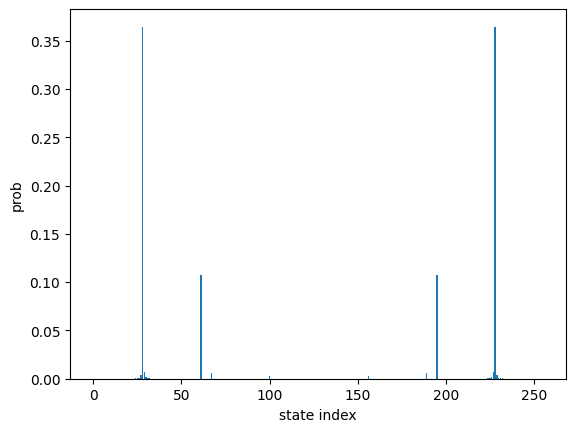

In [10]:
state = quantum_state(n_total_qubits, circuit=qpe_circuit)
vec = evaluate_state_to_vector(state).vector

# レジスタ量子ビットについて周辺化した測定確率を計算 (7.2節参照)
probs_allbits = np.abs(vec)**2
reshaped_array = probs_allbits.reshape(2**n_qpe_register, 2**n_qubits)
probs_regbits = reshaped_array.sum(axis=1)

print("H'の固有値")
print(eigs)
print("H'の固有値に対応する位相")
expected_phases = np.arccos(eigs)  # 値域は[0, pi]であることに注意
print(expected_phases)

# 確率が大きい順に、レジスタ量子ビットの状態と対応する位相を表示
probs_regbits_sorted_indices = np.argsort(probs_regbits)[::-1]
for i in probs_regbits_sorted_indices[:20]: # 確率が大きい上位20個を表示
    if probs_regbits[i] > 1e-4:
        # 位相の推定値. 範囲を[-pi, pi]にしていることに注意
        phase = 2 * np.pi * i / (2**n_qpe_register)  - np.pi
        print(f"インデックス{i:5d}, 位相{phase:+.6f}, 確率 {probs_regbits[i]:.6f}")

# 周辺確率をプロット
import matplotlib.pyplot as plt
plt.bar(np.arange(2**n_qpe_register), probs_regbits)
plt.xlabel("state index")
plt.ylabel("prob")
plt.show()

このように、量子ビット化で用いる演算子$W_H$に対して量子位相推定アルゴリズムを直接適用することで、ハミルトニアンの固有値を推定することができる。